# Additional Experiments

This notebook contains supporting experiments for the paper, including candidate-model comparisons, voting-ensemble comparisons, and hyperparameter searches. These experiments are kept separate from the concise main-results notebook because some of them are computationally expensive.

In [1]:
import itertools
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import StratifiedKFold, train_test_split

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))

from build_and_fit_pipeline import (
    build_and_train_pipeline,
    crossvalidate_full_pipeline,
    search_pipeline,
)
from preprocessing import clean_unit, create_features_and_labels, extract_quantity_keyword

data_path = project_root / "data" / "unit_normalization_dict.csv"

## 1. Candidate-model comparison

In [7]:
# Compare models in the order used in the paper.
# Each supervised model is evaluated with 10-fold CV and one stratified 80/20 split.
unit_dict_new = pd.read_csv(data_path)
X, y_encoded, _ = create_features_and_labels(
    unit_dict_new, extract_quantity_keyword, clean_unit
)

model_definitions = [
    ("Majority-class", "majority", None),
    ("Logistic Regression", "model", "logistic_regression"),
    ("Random Forest", "model", "random_forest"),
    ("SVM", "model", "svm"),
    ("XGBoost", "model", "xgb"),
    ("LightGBM", "model", "lightgbm"),
    ("MLP", "model", "mlp"),
    ("Voting Ensemble", "voting", ["svm", "mlp", "logistic_regression"]),
]

train_X, test_X, train_y, test_y = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

comparison_rows = []
for display_name, model_type, model_specification in model_definitions:
    if model_type == "majority":
        cv_accuracy = []
        cv_f1_weighted = []
        cv_f1_macro = []
        cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
        for cv_train_indices, cv_test_indices in cv.split(X, y_encoded):
            values, counts = np.unique(y_encoded[cv_train_indices], return_counts=True)
            majority_class = values[np.argmax(counts)]
            cv_predictions = np.full(
                len(cv_test_indices), fill_value=majority_class
            )
            cv_true = y_encoded[cv_test_indices]
            cv_accuracy.append(accuracy_score(cv_true, cv_predictions))
            cv_f1_weighted.append(
                f1_score(cv_true, cv_predictions, average="weighted", zero_division=0)
            )
            cv_f1_macro.append(
                f1_score(cv_true, cv_predictions, average="macro", zero_division=0)
            )

        values, counts = np.unique(train_y, return_counts=True)
        majority_class = values[np.argmax(counts)]
        random_predictions = np.full(len(test_y), fill_value=majority_class)
    else:
        voting_models = model_specification if model_type == "voting" else None
        model_name = "voting_classifier" if model_type == "voting" else model_specification
        cv_results = crossvalidate_full_pipeline(
            unit_dict_new=unit_dict_new,
            ml_model=model_name,
            voting_models=voting_models,
            cv_folds=10,
            random_state=42,
        )
        cv_accuracy = cv_results["test_accuracy"]
        cv_f1_weighted = cv_results["test_f1_weighted"]
        cv_f1_macro = cv_results["test_f1_macro"]

        fitted_pipeline = build_and_train_pipeline(
            train_X,
            train_y,
            model_name,
            voting_models=voting_models,
            mode="build_and_train",
        )
        random_predictions = fitted_pipeline.predict(test_X)

    comparison_rows.append(
        {
            "Model": display_name,
            "CV Accuracy": f"{np.mean(cv_accuracy):.4f} +/- {np.std(cv_accuracy):.4f}",
            "CV F1 weighted": f"{np.mean(cv_f1_weighted):.4f} +/- {np.std(cv_f1_weighted):.4f}",
            "CV Macro F1": f"{np.mean(cv_f1_macro):.4f} +/- {np.std(cv_f1_macro):.4f}",
            "Random Accuracy": accuracy_score(test_y, random_predictions),
            "Random F1 weighted": f1_score(
                test_y, random_predictions, average="weighted", zero_division=0
            ),
            "Random Macro F1": f1_score(
                test_y, random_predictions, average="macro", zero_division=0
            ),
        }
    )

model_comparison_df = pd.DataFrame(comparison_rows)
display(model_comparison_df)

Mean CV scores (+/- std):
  Accuracy:      95.02% +/- 1.43%
  F1 (weighted): 95.03% +/- 1.43%
  F1 (macro):    96.11% +/- 1.11%
  F1 (micro):    95.02% +/- 1.43%
Mean CV scores (+/- std):
  Accuracy:      94.32% +/- 1.82%
  F1 (weighted): 94.32% +/- 1.81%
  F1 (macro):    95.61% +/- 1.31%
  F1 (micro):    94.32% +/- 1.82%
Mean CV scores (+/- std):
  Accuracy:      95.19% +/- 1.36%
  F1 (weighted): 95.19% +/- 1.36%
  F1 (macro):    96.28% +/- 1.08%
  F1 (micro):    95.19% +/- 1.36%


c:\Users\up19040\Projekte\LMU\Programmieren mit LMU\unit_harmonization\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Mean CV scores (+/- std):
  Accuracy:      94.32% +/- 1.61%
  F1 (weighted): 94.32% +/- 1.61%
  F1 (macro):    95.54% +/- 1.27%
  F1 (micro):    94.32% +/- 1.61%
Mean CV scores (+/- std):
  Accuracy:      94.81% +/- 1.22%
  F1 (weighted): 94.80% +/- 1.21%
  F1 (macro):    95.98% +/- 1.01%
  F1 (micro):    94.81% +/- 1.22%
Mean CV scores (+/- std):
  Accuracy:      94.92% +/- 1.03%
  F1 (weighted): 94.93% +/- 1.03%
  F1 (macro):    96.03% +/- 0.81%
  F1 (micro):    94.92% +/- 1.03%
Mean CV scores (+/- std):
  Accuracy:      95.51% +/- 1.33%
  F1 (weighted): 95.53% +/- 1.32%
  F1 (macro):    96.55% +/- 1.03%
  F1 (micro):    95.51% +/- 1.33%


c:\Users\up19040\Projekte\LMU\Programmieren mit LMU\unit_harmonization\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,Model,CV Accuracy,CV F1 weighted,CV Macro F1,Random Accuracy,Random F1 weighted,Random Macro F1
0,Majority-class,0.3067 +/- 0.0026,0.1439 +/- 0.0022,0.0587 +/- 0.0004,0.305405,0.142902,0.058489
1,Logistic Regression,0.9502 +/- 0.0143,0.9503 +/- 0.0143,0.9611 +/- 0.0111,0.956757,0.956917,0.964241
2,Random Forest,0.9432 +/- 0.0182,0.9432 +/- 0.0181,0.9561 +/- 0.0131,0.932432,0.932589,0.942927
3,SVM,0.9519 +/- 0.0136,0.9519 +/- 0.0136,0.9628 +/- 0.0108,0.956757,0.957083,0.967775
4,XGBoost,0.9432 +/- 0.0161,0.9432 +/- 0.0161,0.9554 +/- 0.0127,0.948649,0.948761,0.959292
5,LightGBM,0.9481 +/- 0.0122,0.9480 +/- 0.0121,0.9598 +/- 0.0101,0.956757,0.956826,0.965683
6,MLP,0.9492 +/- 0.0103,0.9493 +/- 0.0103,0.9603 +/- 0.0081,0.964865,0.964799,0.975099
7,Voting Ensemble,0.9551 +/- 0.0133,0.9553 +/- 0.0132,0.9655 +/- 0.0103,0.956757,0.956934,0.964743


## 2. Publication tables for the robustness analysis

The following cells generate the tables reported in the paper from the final dictionary-derived dataset. The robustness split follows the project's `stratified_split_by_count` procedure: manually curated low-frequency entries are prioritized for testing, the test set is capped at 20% within each class, and LLM-generated variants remain available for training but are excluded from the test set.

In [7]:
# Table A: class distribution by data source.
from preprocessing import stratified_split_by_count

publication_data = pd.read_csv(data_path).copy()
publication_data["source"] = publication_data["source"].str.lower()
publication_data["data_source"] = np.where(
    publication_data["source"].eq("manual"), "Manual", "Augmented"
)
class_order = [
    "t CO2e", "kt CO2e", "Mt CO2e", "kg CO2e",
    "USt CO2e", "10 kt CO2e", "MM Mt CO2e", "Other",
]
source_counts = (
    publication_data.groupby(["normalized_unit", "data_source"])
    .size().unstack(fill_value=0).reindex(class_order, fill_value=0)
)
for column in ["Manual", "Augmented"]:
    if column not in source_counts:
        source_counts[column] = 0
source_counts["Total"] = source_counts[["Manual", "Augmented"]].sum(axis=1)
manual_total = int(source_counts["Manual"].sum())
class_distribution_table = source_counts[["Manual", "Augmented", "Total"]].copy()
class_distribution_table["Manual (Proportion)"] = class_distribution_table.apply(
    lambda row: f"{int(row['Manual'])} ({row['Manual'] / manual_total:.1%})", axis=1
)
class_distribution_table = class_distribution_table[
    ["Manual (Proportion)", "Augmented", "Total"]
]
class_distribution_table.loc["Total"] = [
    f"{manual_total} (100.0%)", int(source_counts["Augmented"].sum()),
    int(source_counts["Total"].sum()),
]
print("Class distribution by data source")
display(class_distribution_table)

# Build the canonical rare-unit split used by the project and the paper tables.
X_robust, y_robust, _ = create_features_and_labels(
    publication_data, extract_quantity_keyword, clean_unit
)
robust_train_X, robust_train_y, robust_test_X, robust_test_y = stratified_split_by_count(
    publication_data, X_robust, y_robust, max_count=5,
    include_artificial=False, random_state=42,
)
train_indices = robust_train_X["orig_index"].to_numpy()
test_indices = robust_test_X["orig_index"].to_numpy()

# Table B: train-test composition by class and data source.
rare_composition_table = pd.DataFrame(index=class_order)
for column_name, source_name, indices in [
    ("Rare test", "Manual", test_indices),
    ("Manual train", "Manual", train_indices),
    ("Aug. train", "Augmented", train_indices),
]:
    rare_composition_table[column_name] = [
        int(
            (
                publication_data.loc[indices, "normalized_unit"].eq(unit_class)
                & publication_data.loc[indices, "data_source"].eq(source_name)
            ).sum()
        )
        for unit_class in class_order
    ]
rare_composition_table["Manual total"] = (
    rare_composition_table["Rare test"] + rare_composition_table["Manual train"]
)
rare_composition_table["Total train"] = (
    rare_composition_table["Manual train"] + rare_composition_table["Aug. train"]
)
rare_composition_table = rare_composition_table[
    ["Manual total", "Rare test", "Manual train", "Aug. train", "Total train"]
]
rare_composition_table.loc["Total"] = rare_composition_table.sum(axis=0)
print("Rare-unit train-test composition")
display(rare_composition_table)

# Table C: candidate-model performance on the fixed rare-unit test set.
robustness_model_definitions = [
    ("Logistic Regression", "logistic_regression", None),
    ("Random Forest", "random_forest", None),
    ("SVM", "svm", None),
    ("XGBoost", "xgb", None),
    ("LightGBM", "lightgbm", None),
    ("MLP", "mlp", None),
    ("Voting Ensemble", "voting_classifier", ["svm", "mlp", "logistic_regression"]),
]
robustness_rows = []
for display_name, model_name, voting_models in robustness_model_definitions:
    robustness_pipeline = build_and_train_pipeline(
        robust_train_X, robust_train_y, model_name,
        voting_models=voting_models, mode="build_and_train",
    )
    robust_predictions = robustness_pipeline.predict(robust_test_X)
    robustness_rows.append({
        "Model": display_name,
        "Accuracy": accuracy_score(robust_test_y, robust_predictions),
        "F1 weighted": f1_score(
            robust_test_y, robust_predictions, average="weighted", zero_division=0
        ),
        "Macro F1": f1_score(
            robust_test_y, robust_predictions, average="macro", zero_division=0
        ),
    })
robustness_model_results = pd.DataFrame(robustness_rows).set_index("Model")
print("Robustness evaluation on rare real-world unit strings")
display(robustness_model_results.round(4))

Class distribution by data source


data_source,Manual (Proportion),Augmented,Total
normalized_unit,,,
t CO2e,343 (24.9%),0,343
kt CO2e,249 (18.1%),0,249
Mt CO2e,184 (13.4%),0,184
kg CO2e,25 (1.8%),101,126
USt CO2e,4 (0.3%),112,116
10 kt CO2e,4 (0.3%),116,120
MM Mt CO2e,2 (0.1%),142,144
Other,567 (41.1%),0,567
Total,1378 (100.0%),471,1849


Rare-unit train-test composition


,Manual total,Rare test,Manual train,Aug. train,Total train
t CO2e,343,68,275,0,275
kt CO2e,249,49,200,0,200
Mt CO2e,184,36,148,0,148
kg CO2e,25,19,6,101,107
USt CO2e,4,4,0,112,112
10 kt CO2e,4,1,3,116,119
MM Mt CO2e,2,1,1,142,143
Other,567,113,454,0,454
Total,1378,291,1087,471,1558


c:\Users\up19040\Projekte\LMU\Programmieren mit LMU\unit_harmonization\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\up19040\Projekte\LMU\Programmieren mit LMU\unit_harmonization\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Robustness evaluation on rare real-world unit strings


,Accuracy,F1 weighted,Macro F1
Model,,,
Logistic Regression,0.9416,0.9412,0.9632
Random Forest,0.9210,0.9193,0.8264
SVM,0.9347,0.9347,0.8365
XGBoost,0.8969,0.8962,0.7726
LightGBM,0.9072,0.9072,0.8233
MLP,0.9347,0.9345,0.9593
Voting Ensemble,0.9519,0.9519,0.9722


## 2. Voting-ensemble subset comparison

In [8]:
# Compare voting-ensemble subsets with at least three base models.
all_models = ["xgb", "lightgbm", "logistic_regression", "random_forest", "svm", "mlp"]
voting_results = []

for subset_size in range(3, len(all_models) + 1):
    for combination in itertools.combinations(all_models, subset_size):
        scores = crossvalidate_full_pipeline(
            unit_dict_new=pd.read_csv(data_path),
            ml_model="voting_classifier",
            voting_models=list(combination),
            cv_folds=10,
            random_state=42,
        )
        voting_results.append(
            {
                "models": ", ".join(combination),
                "accuracy_mean": scores["test_accuracy"].mean(),
                "f1_weighted_mean": scores["test_f1_weighted"].mean(),
                "f1_macro_mean": scores["test_f1_macro"].mean(),
            }
        )

voting_results_df = pd.DataFrame(voting_results).sort_values(
    "f1_weighted_mean", ascending=False
)
display(voting_results_df)

Mean CV scores (+/- std):
  Accuracy:      94.86% +/- 1.50%
  F1 (weighted): 94.86% +/- 1.49%
  F1 (macro):    95.98% +/- 1.07%
  F1 (micro):    94.86% +/- 1.50%
Mean CV scores (+/- std):
  Accuracy:      94.64% +/- 1.52%
  F1 (weighted): 94.64% +/- 1.51%
  F1 (macro):    95.80% +/- 1.22%
  F1 (micro):    94.64% +/- 1.52%
Mean CV scores (+/- std):
  Accuracy:      95.02% +/- 1.30%
  F1 (weighted): 95.02% +/- 1.29%
  F1 (macro):    96.08% +/- 1.00%
  F1 (micro):    95.02% +/- 1.30%
Mean CV scores (+/- std):
  Accuracy:      94.81% +/- 1.42%
  F1 (weighted): 94.81% +/- 1.41%
  F1 (macro):    95.99% +/- 1.02%
  F1 (micro):    94.81% +/- 1.42%
Mean CV scores (+/- std):
  Accuracy:      94.97% +/- 1.64%
  F1 (weighted): 94.97% +/- 1.63%
  F1 (macro):    96.16% +/- 1.14%
  F1 (micro):    94.97% +/- 1.64%
Mean CV scores (+/- std):
  Accuracy:      95.35% +/- 1.68%
  F1 (weighted): 95.35% +/- 1.68%
  F1 (macro):    96.37% +/- 1.37%
  F1 (micro):    95.35% +/- 1.68%
Mean CV scores (+/- std):
  

,models,accuracy_mean,f1_weighted_mean,f1_macro_mean
34,"logistic_regression, random_forest, svm, mlp",0.957268,0.957359,0.968232
32,"lightgbm, logistic_regression, svm, mlp",0.956730,0.956792,0.967450
28,"xgb, logistic_regression, svm, mlp",0.956190,0.956248,0.966896
18,"logistic_regression, svm, mlp",0.955106,0.955251,0.965537
11,"lightgbm, logistic_regression, svm",0.955103,0.955104,0.965457
40,"lightgbm, logistic_regression, random_forest, ...",0.955100,0.955082,0.965907
15,"lightgbm, svm, mlp",0.954559,0.954622,0.965036
39,"xgb, logistic_regression, random_forest, svm, mlp",0.954559,0.954559,0.965822
30,"lightgbm, logistic_regression, random_forest, svm",0.954565,0.954533,0.966242
19,"random_forest, svm, mlp",0.954016,0.954075,0.965178


## 3. Hyperparameter searches

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters (GridSearch): {'clf__colsample_bytree': 0.8, 'clf__gamma': None, 'clf__learning_rate': 0.2, 'clf__max_depth': 6, 'clf__n_estimators': 100, 'clf__reg_alpha': None, 'clf__reg_lambda': 1.5, 'clf__subsample': 1}
Best accuracy: 0.9392
Best f1: 0.9391
Best logloss: -0.2400
=== MAIN METRICS ===
Accuracy:          95.14%
F1-score weighted: 95.15%
F1-score macro:    96.18%

F1-score micro:    95.14%

=== ADDITIONAL METRICS (weighted) ===
Precision:         95.21%
Recall:            95.14%
F1-score weighted: 95.15%

=== ERROR STATISTICS AND PER-CLASS METRICS ===
            mean_error  count  precision  recall      f1  support
true_label                                                       
kt CO2e         0.0800     50     0.9583  0.9200  0.9388       50
t CO2e          0.0725     69     0.8889  0.9275  0.9078       69
Mt CO2e         0.0541     37     0.9211  0.9459  0.9333       37
Other           0.0531    113    

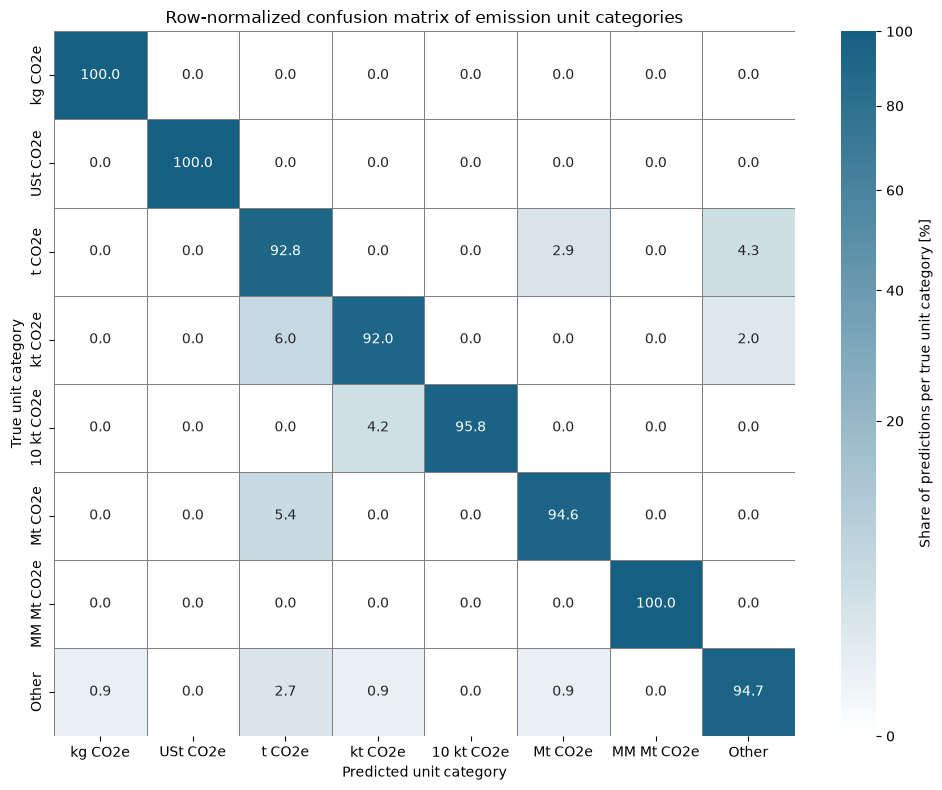


Most frequent confusions:
 Predicted Label  10 kt CO2e  MM Mt CO2e  Mt CO2e  Other  USt CO2e  kg CO2e  \
True Label                                                                   
10 kt CO2e               23           0        0      0         0        0   
MM Mt CO2e                0          29        0      0         0        0   
Mt CO2e                   0           0       35      0         0        0   
Other                     0           0        1    107         0        1   
USt CO2e                  0           0        0      0        23        0   
kg CO2e                   0           0        0      0         0       25   
kt CO2e                   0           0        0      1         0        0   
t CO2e                    0           0        2      3         0        0   

Predicted Label  kt CO2e  t CO2e  
True Label                        
10 kt CO2e             1       0  
MM Mt CO2e             0       0  
Mt CO2e                0       2  
Other           

In [9]:
# XGBoost hyperparameter search
xgb_param_space = {
    "clf__max_depth": [4, 6],
    "clf__learning_rate": [0.2],
    "clf__n_estimators": [100, 300],
    "clf__subsample": [1],
    "clf__colsample_bytree": [0.8],
    "clf__gamma": [None, 0.3],
    "clf__reg_alpha": [None, 0.1],
    "clf__reg_lambda": [None, 1.5],
}

xgb_search, xgb_stats = search_pipeline(
    param_space=xgb_param_space,
    unit_dict_new=pd.read_csv(data_path),
    ml_model="xgb",
    mode="grid",
    scoring={
        "accuracy": "accuracy",
        "f1": "f1_weighted",
        "logloss": "neg_log_loss",
    },
    refit="f1",
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Best parameters (GridSearch): {'clf__bagging_freq': 0, 'clf__feature_fraction': 1.0, 'clf__learning_rate': 0.1, 'clf__max_depth': 6, 'clf__n_estimators': 600, 'clf__num_leaves': 31, 'clf__reg_lambda': 0.0}
Best accuracy: 0.9405
Best f1: 0.9404
Best logloss: -0.4390
=== MAIN METRICS ===
Accuracy:          95.14%
F1-score weighted: 95.15%
F1-score macro:    96.25%

F1-score micro:    95.14%

=== ADDITIONAL METRICS (weighted) ===
Precision:         95.20%
Recall:            95.14%
F1-score weighted: 95.15%

=== ERROR STATISTICS AND PER-CLASS METRICS ===
            mean_error  count  precision  recall      f1  support
true_label                                                       
Mt CO2e         0.0811     37     0.9189  0.9189  0.9189       37
t CO2e          0.0725     69     0.8889  0.9275  0.9078       69
Other           0.0619    113     0.9636  0.9381  0.9507      113
kt CO2e         0.0600     50     0.9792  0.9400 

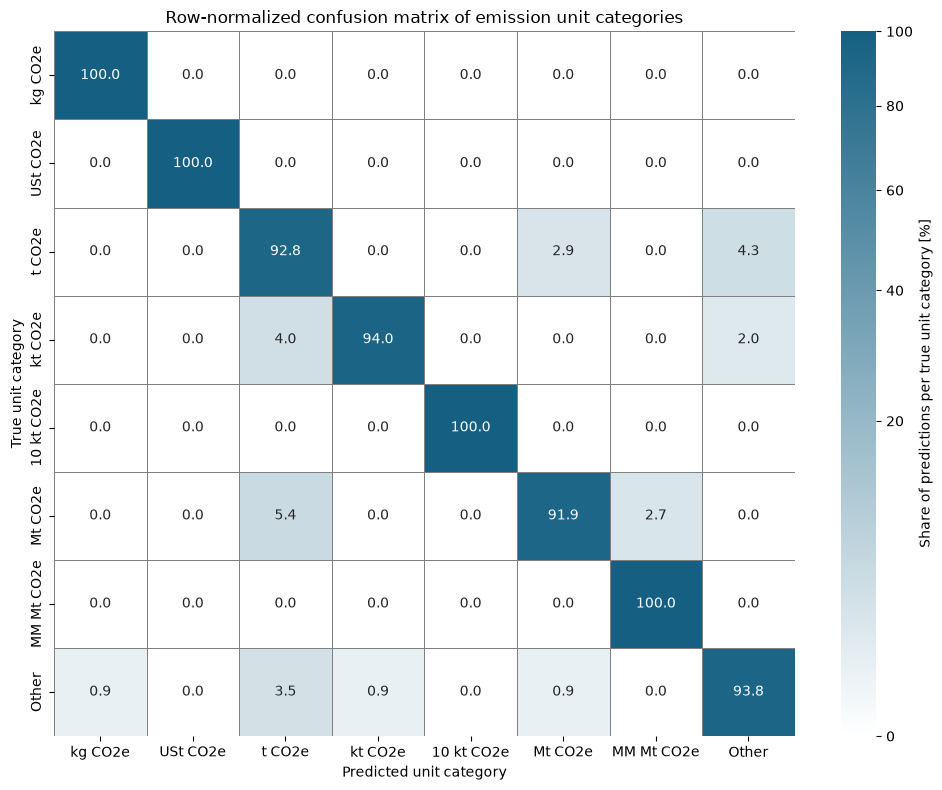


Most frequent confusions:
 Predicted Label  10 kt CO2e  MM Mt CO2e  Mt CO2e  Other  USt CO2e  kg CO2e  \
True Label                                                                   
10 kt CO2e               24           0        0      0         0        0   
MM Mt CO2e                0          29        0      0         0        0   
Mt CO2e                   0           1       34      0         0        0   
Other                     0           0        1    106         0        1   
USt CO2e                  0           0        0      0        23        0   
kg CO2e                   0           0        0      0         0       25   
kt CO2e                   0           0        0      1         0        0   
t CO2e                    0           0        2      3         0        0   

Predicted Label  kt CO2e  t CO2e  
True Label                        
10 kt CO2e             0       0  
MM Mt CO2e             0       0  
Mt CO2e                0       2  
Other           

In [10]:
## LightGBM hyperparameter search
lightgbm_param_space = {
    "clf__num_leaves": [31, 63],
    "clf__max_depth": [-1, 6, 8],
    "clf__n_estimators": [100, 200, 600],
    "clf__learning_rate": [0.05, 0.1],
    "clf__feature_fraction": [0.8, 1.0],
    "clf__bagging_freq": [0, 1],
    "clf__reg_lambda": [0.0, 2.0],
}

lightgbm_search, lightgbm_stats = search_pipeline(
    param_space=lightgbm_param_space,
    unit_dict_new=pd.read_csv(data_path),
    ml_model="lightgbm",
    mode="grid",
)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


c:\Users\up19040\Projekte\LMU\Programmieren mit LMU\unit_harmonization\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Best parameters (GridSearch): {'clf__C': 100.0, 'clf__class_weight': 'balanced', 'clf__max_iter': 1000, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Best accuracy: 0.9473
Best f1: 0.9474
Best logloss: -0.2080


c:\Users\up19040\Projekte\LMU\Programmieren mit LMU\unit_harmonization\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


=== MAIN METRICS ===
Accuracy:          95.95%
F1-score weighted: 95.96%
F1-score macro:    96.69%

F1-score micro:    95.95%

=== ADDITIONAL METRICS (weighted) ===
Precision:         96.03%
Recall:            95.95%
F1-score weighted: 95.96%

=== ERROR STATISTICS AND PER-CLASS METRICS ===
            mean_error  count  precision  recall      f1  support
true_label                                                       
kt CO2e         0.0800     50     1.0000  0.9200  0.9583       50
t CO2e          0.0725     69     0.9014  0.9275  0.9143       69
Mt CO2e         0.0541     37     0.9211  0.9459  0.9333       37
Other           0.0354    113     0.9732  0.9646  0.9689      113
10 kt CO2e      0.0000     24     0.9600  1.0000  0.9796       24
MM Mt CO2e      0.0000     29     1.0000  1.0000  1.0000       29
kg CO2e         0.0000     25     0.9615  1.0000  0.9804       25
USt CO2e        0.0000     23     1.0000  1.0000  1.0000       23


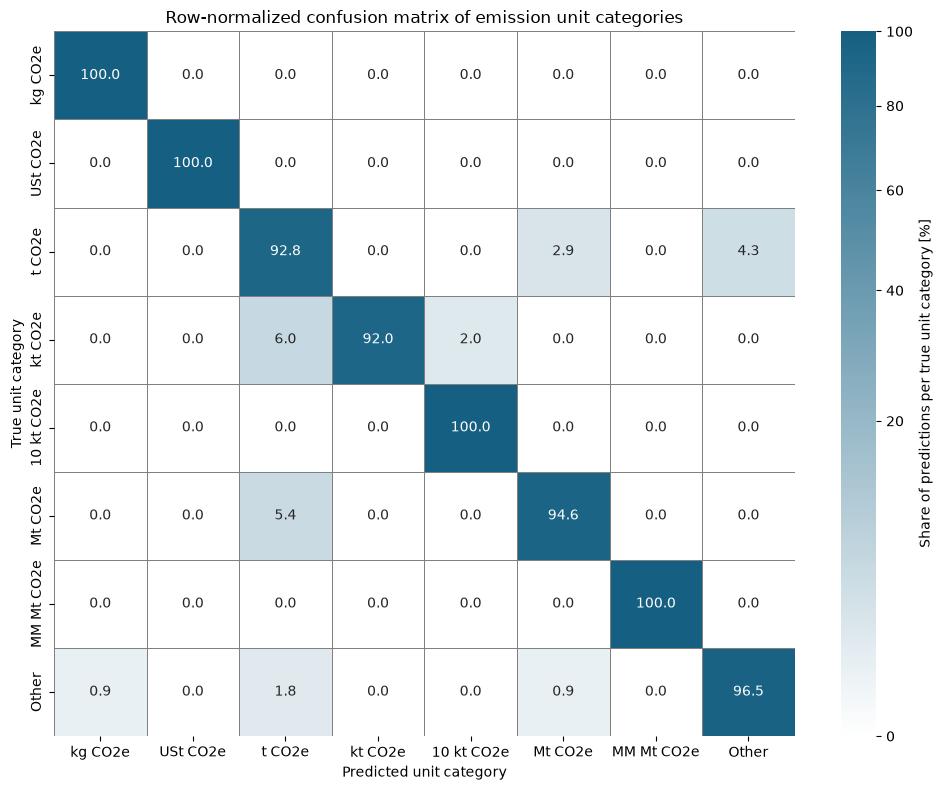


Most frequent confusions:
 Predicted Label  10 kt CO2e  MM Mt CO2e  Mt CO2e  Other  USt CO2e  kg CO2e  \
True Label                                                                   
10 kt CO2e               24           0        0      0         0        0   
MM Mt CO2e                0          29        0      0         0        0   
Mt CO2e                   0           0       35      0         0        0   
Other                     0           0        1    109         0        1   
USt CO2e                  0           0        0      0        23        0   
kg CO2e                   0           0        0      0         0       25   
kt CO2e                   1           0        0      0         0        0   
t CO2e                    0           0        2      3         0        0   

Predicted Label  kt CO2e  t CO2e  
True Label                        
10 kt CO2e             0       0  
MM Mt CO2e             0       0  
Mt CO2e                0       2  
Other           

In [11]:
## Logistic-regression hyperparameter search
logistic_param_space = {
    "clf__C": [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
    "clf__penalty": ["l2"],
    "clf__class_weight": [None, "balanced"],
    "clf__solver": ["lbfgs", "newton-cg"],
    "clf__max_iter": [1000, 2000, 3000],
}

logistic_search, logistic_stats = search_pipeline(
    param_space=logistic_param_space,
    unit_dict_new=pd.read_csv(data_path),
    ml_model="logistic_regression",
    mode="grid",
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\up19040\Projekte\LMU\Programmieren mit LMU\unit_harmonization\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Best parameters (GridSearch): {'clf__C': 100.0, 'clf__class_weight': 'balanced', 'clf__max_iter': 2000, 'clf__penalty': 'l2', 'clf__solver': 'saga'}
Best accuracy: 0.9459
Best f1: 0.9461
Best logloss: -0.2170


c:\Users\up19040\Projekte\LMU\Programmieren mit LMU\unit_harmonization\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


=== MAIN METRICS ===
Accuracy:          95.14%
F1-score weighted: 95.16%
F1-score macro:    95.91%

F1-score micro:    95.14%

=== ADDITIONAL METRICS (weighted) ===
Precision:         95.28%
Recall:            95.14%
F1-score weighted: 95.16%

=== ERROR STATISTICS AND PER-CLASS METRICS ===
            mean_error  count  precision  recall      f1  support
true_label                                                       
Mt CO2e         0.0811     37     0.8947  0.9189  0.9067       37
kt CO2e         0.0800     50     1.0000  0.9200  0.9583       50
t CO2e          0.0725     69     0.8889  0.9275  0.9078       69
Other           0.0531    113     0.9727  0.9469  0.9596      113
10 kt CO2e      0.0000     24     0.9231  1.0000  0.9600       24
MM Mt CO2e      0.0000     29     1.0000  1.0000  1.0000       29
kg CO2e         0.0000     25     0.9615  1.0000  0.9804       25
USt CO2e        0.0000     23     1.0000  1.0000  1.0000       23


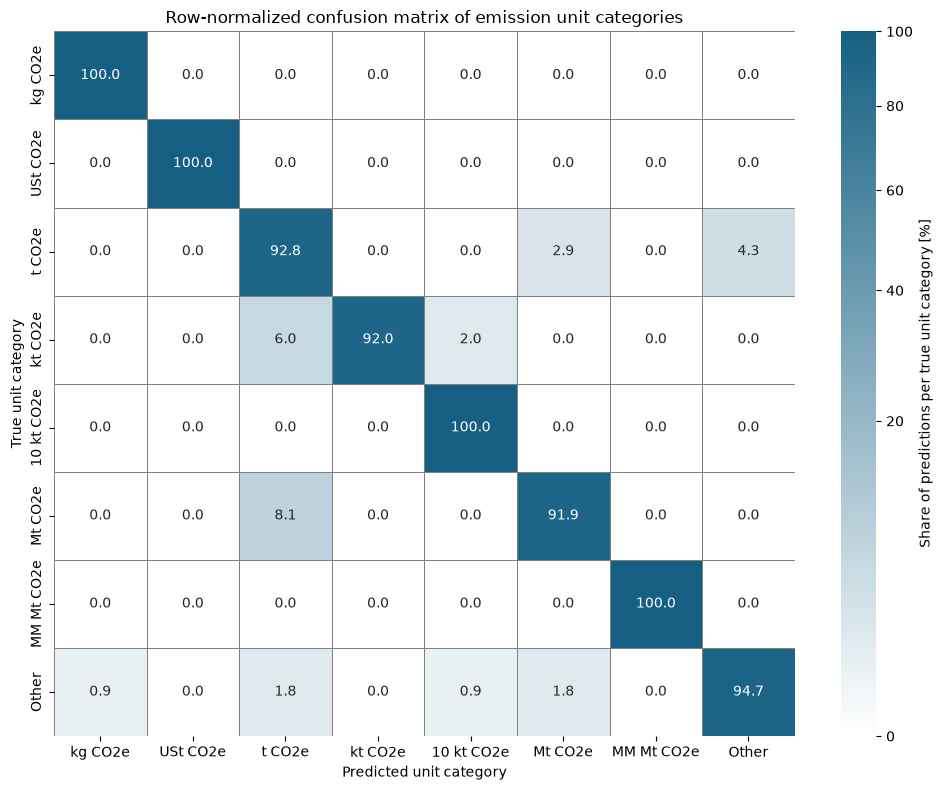


Most frequent confusions:
 Predicted Label  10 kt CO2e  MM Mt CO2e  Mt CO2e  Other  USt CO2e  kg CO2e  \
True Label                                                                   
10 kt CO2e               24           0        0      0         0        0   
MM Mt CO2e                0          29        0      0         0        0   
Mt CO2e                   0           0       34      0         0        0   
Other                     1           0        2    107         0        1   
USt CO2e                  0           0        0      0        23        0   
kg CO2e                   0           0        0      0         0       25   
kt CO2e                   1           0        0      0         0        0   
t CO2e                    0           0        2      3         0        0   

Predicted Label  kt CO2e  t CO2e  
True Label                        
10 kt CO2e             0       0  
MM Mt CO2e             0       0  
Mt CO2e                0       3  
Other           

In [12]:
## Logistic-regression search with the SAGA solver
saga_param_space = {
    "clf__C": [0.01, 0.1, 1.0, 10.0, 100.0],
    "clf__penalty": ["l1", "l2"],
    "clf__class_weight": [None, "balanced"],
    "clf__solver": ["saga"],
    "clf__max_iter": [2000],
}

saga_search, saga_stats = search_pipeline(
    param_space=saga_param_space,
    unit_dict_new=pd.read_csv(data_path),
    ml_model="logistic_regression",
    mode="grid",
)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Best parameters (GridSearch): {'clf__bootstrap': False, 'clf__class_weight': None, 'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
Best accuracy: 0.9385
Best f1: 0.9383
Best logloss: -0.3003
=== MAIN METRICS ===
Accuracy:          93.51%
F1-score weighted: 93.55%
F1-score macro:    94.95%

F1-score micro:    93.51%

=== ADDITIONAL METRICS (weighted) ===
Precision:         93.72%
Recall:            93.51%
F1-score weighted: 93.55%

=== ERROR STATISTICS AND PER-CLASS METRICS ===
            mean_error  count  precision  recall      f1  support
true_label                                                       
kt CO2e         0.1000     50     0.9574  0.9000  0.9278       50
Other           0.0885    113     0.9537  0.9115  0.9321      113
Mt CO2e         0.0811     37     0.8947  0.9189  0.9067       37
t CO2e          0.0725     69     0.

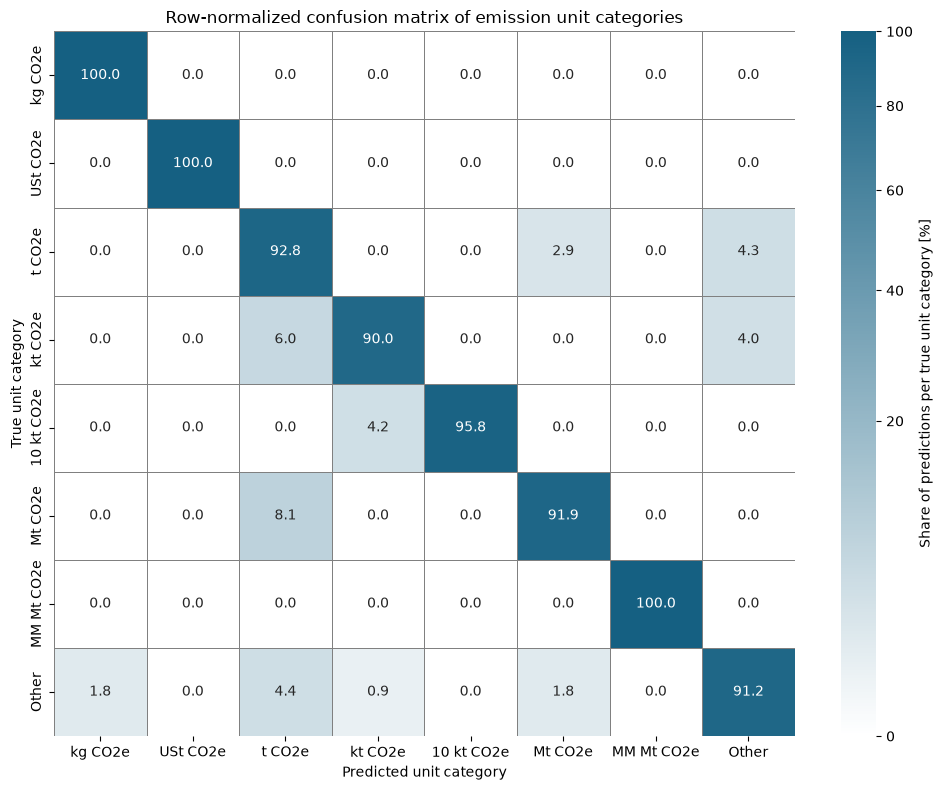


Most frequent confusions:
 Predicted Label  10 kt CO2e  MM Mt CO2e  Mt CO2e  Other  USt CO2e  kg CO2e  \
True Label                                                                   
10 kt CO2e               23           0        0      0         0        0   
MM Mt CO2e                0          29        0      0         0        0   
Mt CO2e                   0           0       34      0         0        0   
Other                     0           0        2    103         0        2   
USt CO2e                  0           0        0      0        23        0   
kg CO2e                   0           0        0      0         0       25   
kt CO2e                   0           0        0      2         0        0   
t CO2e                    0           0        2      3         0        0   

Predicted Label  kt CO2e  t CO2e  
True Label                        
10 kt CO2e             1       0  
MM Mt CO2e             0       0  
Mt CO2e                0       3  
Other           

In [13]:
## Random-forest hyperparameter search
random_forest_param_space = {
    "clf__n_estimators": [100, 200, 500],
    "clf__max_depth": [None, 10, 20],
    "clf__min_samples_split": [2, 10],
    "clf__min_samples_leaf": [1, 4],
    "clf__max_features": ["sqrt", "log2"],
    "clf__bootstrap": [True, False],
    "clf__class_weight": [None, "balanced"],
}

random_forest_search, random_forest_stats = search_pipeline(
    param_space=random_forest_param_space,
    unit_dict_new=pd.read_csv(data_path),
    ml_model="random_forest",
    mode="grid",
)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


c:\Users\up19040\Projekte\LMU\Programmieren mit LMU\unit_harmonization\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Best parameters (GridSearch): {'clf__C': 100, 'clf__class_weight': None, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}
Best accuracy: 0.9452
Best f1: 0.9451
Best logloss: -0.2233


c:\Users\up19040\Projekte\LMU\Programmieren mit LMU\unit_harmonization\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


=== MAIN METRICS ===
Accuracy:          94.86%
F1-score weighted: 94.89%
F1-score macro:    96.01%

F1-score micro:    94.86%

=== ADDITIONAL METRICS (weighted) ===
Precision:         94.99%
Recall:            94.86%
F1-score weighted: 94.89%

=== ERROR STATISTICS AND PER-CLASS METRICS ===
            mean_error  count  precision  recall      f1  support
true_label                                                       
kt CO2e         0.1000     50     0.9783  0.9000  0.9375       50
Mt CO2e         0.0811     37     0.8947  0.9189  0.9067       37
t CO2e          0.0725     69     0.8767  0.9275  0.9014       69
Other           0.0531    113     0.9640  0.9469  0.9554      113
10 kt CO2e      0.0000     24     0.9600  1.0000  0.9796       24
MM Mt CO2e      0.0000     29     1.0000  1.0000  1.0000       29
kg CO2e         0.0000     25     1.0000  1.0000  1.0000       25
USt CO2e        0.0000     23     1.0000  1.0000  1.0000       23


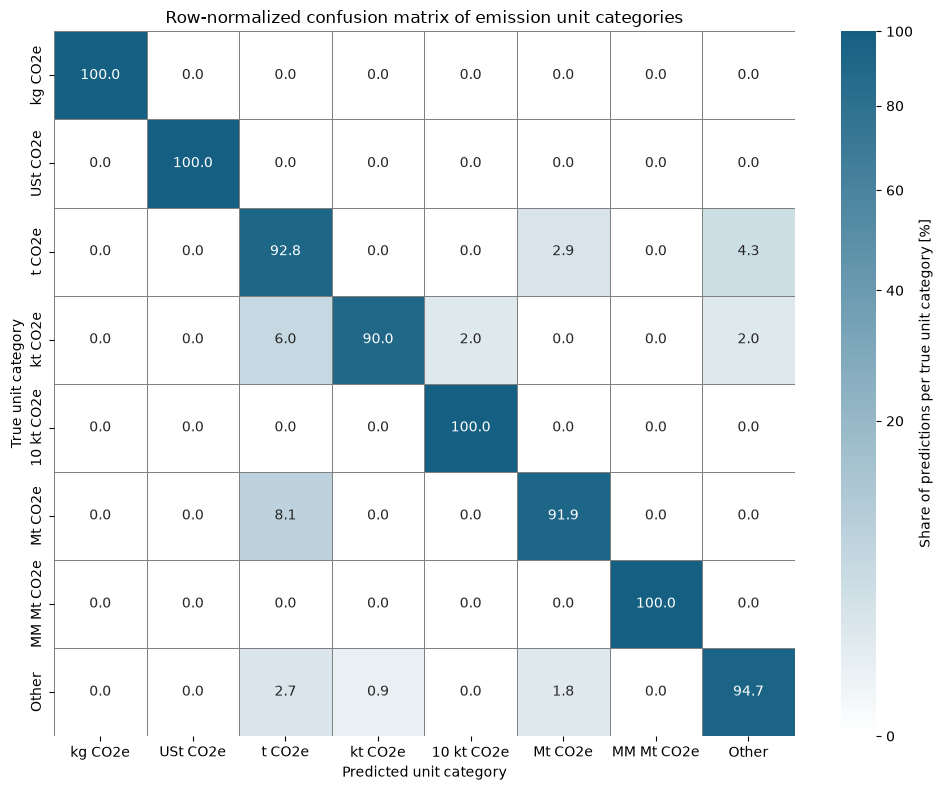


Most frequent confusions:
 Predicted Label  10 kt CO2e  MM Mt CO2e  Mt CO2e  Other  USt CO2e  kg CO2e  \
True Label                                                                   
10 kt CO2e               24           0        0      0         0        0   
MM Mt CO2e                0          29        0      0         0        0   
Mt CO2e                   0           0       34      0         0        0   
Other                     0           0        2    107         0        0   
USt CO2e                  0           0        0      0        23        0   
kg CO2e                   0           0        0      0         0       25   
kt CO2e                   1           0        0      1         0        0   
t CO2e                    0           0        2      3         0        0   

Predicted Label  kt CO2e  t CO2e  
True Label                        
10 kt CO2e             0       0  
MM Mt CO2e             0       0  
Mt CO2e                0       3  
Other           

In [14]:
## Support-vector-machine hyperparameter search
svm_param_space = {
    "clf__C": [0.1, 1, 10, 100],
    "clf__kernel": ["linear", "rbf"],
    "clf__gamma": ["scale", "auto"],
    "clf__class_weight": [None, "balanced"],
}

svm_search, svm_stats = search_pipeline(
    param_space=svm_param_space,
    unit_dict_new=pd.read_csv(data_path),
    ml_model="svm",
    mode="grid",
)

Fitting 5 folds for each of 384 candidates, totalling 1920 fits
Best parameters (GridSearch): {'clf__activation': 'tanh', 'clf__alpha': 0.001, 'clf__early_stopping': True, 'clf__hidden_layer_sizes': (200, 100), 'clf__learning_rate_init': 0.001, 'clf__max_iter': 500, 'clf__solver': 'lbfgs'}
Best accuracy: 0.9466
Best f1: 0.9467
Best logloss: -0.7524
=== MAIN METRICS ===
Accuracy:          96.49%
F1-score weighted: 96.48%
F1-score macro:    97.51%

F1-score micro:    96.49%

=== ADDITIONAL METRICS (weighted) ===
Precision:         96.52%
Recall:            96.49%
F1-score weighted: 96.48%

=== ERROR STATISTICS AND PER-CLASS METRICS ===
            mean_error  count  precision  recall      f1  support
true_label                                                       
t CO2e          0.0725     69     0.9412  0.9275  0.9343       69
Other           0.0531    113     0.9640  0.9469  0.9554      113
kt CO2e         0.0400     50     0.9796  0.9600  0.9697       50
10 kt CO2e      0.0000     2

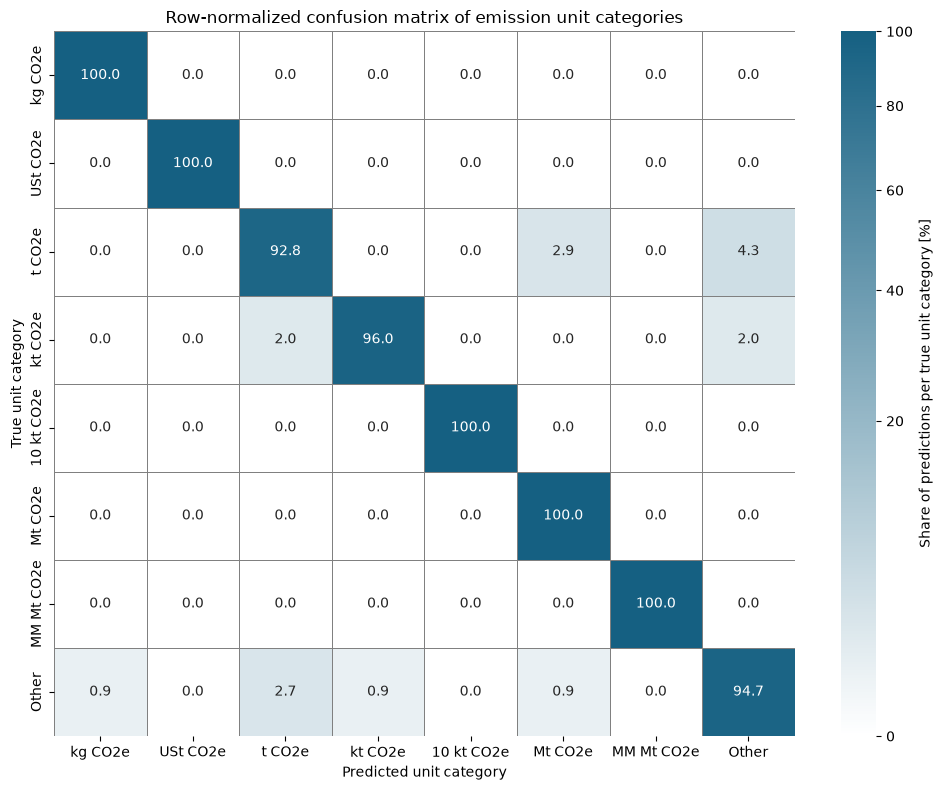


Most frequent confusions:
 Predicted Label  10 kt CO2e  MM Mt CO2e  Mt CO2e  Other  USt CO2e  kg CO2e  \
True Label                                                                   
10 kt CO2e               24           0        0      0         0        0   
MM Mt CO2e                0          29        0      0         0        0   
Mt CO2e                   0           0       37      0         0        0   
Other                     0           0        1    107         0        1   
USt CO2e                  0           0        0      0        23        0   
kg CO2e                   0           0        0      0         0       25   
kt CO2e                   0           0        0      1         0        0   
t CO2e                    0           0        2      3         0        0   

Predicted Label  kt CO2e  t CO2e  
True Label                        
10 kt CO2e             0       0  
MM Mt CO2e             0       0  
Mt CO2e                0       0  
Other           

In [15]:
## Multi-layer perceptron hyperparameter search
mlp_param_space = {
    "clf__hidden_layer_sizes": [(100,), (200,), (100, 100), (200, 100)],
    "clf__activation": ["relu", "tanh"],
    "clf__alpha": [1e-5, 1e-4, 1e-3],
    "clf__learning_rate_init": [0.001, 0.01],
    "clf__solver": ["adam", "lbfgs"],
    "clf__max_iter": [500, 1000],
    "clf__early_stopping": [True, False],
}

mlp_search, mlp_stats = search_pipeline(
    param_space=mlp_param_space,
    unit_dict_new=pd.read_csv(data_path),
    ml_model="mlp",
    mode="grid",
)